# AML s26 - Naive Bayes for spam detection


### Load libraries

In [1]:
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay as cmd

### Load the data

In [2]:
df = pd.read_csv('spam_ham_01.csv')
df

,IsSpam,Text
0,1,"""WINNER!! You have been selected for a $1000 ..."
1,1,"""FREE entry! Text WIN to 80123 and claim your..."
2,1,"""Congratulations! Your mobile number has won ..."
3,1,"""URGENT: Your loan of $3000 is approved. Call..."
4,1,"""You have won a guaranteed cash award. Call 0..."
5,1,"""SIX chances to win CASH! Text CASH to 84484 ..."
6,1,"""FREE ringtone! Reply RING and get your free ..."
7,1,"""Claim your free gift now! Call 0800-GIFT and..."
8,1,"""Your account has been credited with cash. Ca..."
9,1,"""Urgent! You have been selected for our custo..."


### Check for duplicate rows in the dataset

In [3]:
df.groupby('IsSpam').describe()

Text                                                               
       count unique                                                top freq
IsSpam                                                                     
0         15     15    "Hey are you coming to the party tonight? Le...    1
1         15     15   "WINNER!! You have been selected for a $1000 ...    1

### Use [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) to vectorize the text in the DataFrame's "Text" column using Scikit's built-in dictionary of English stop words

In [4]:
vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words='english')
x = vectorizer.fit_transform(df['Text'])
y = df['IsSpam']

print(type(x))

<class 'scipy.sparse._csr.csr_matrix'>


### Split into training and testing set

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)  

## Train a Naive Bayes classifier

The next step is to train a Naive Bayes classifier. We'll use scikit-learn's [MultinomialDB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) classifier, which is ideal for datasets vectorized by `CountVectorizer`.

In [6]:
model = MultinomialNB()
model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Test the trained model on the test set 

0.8333333333333334

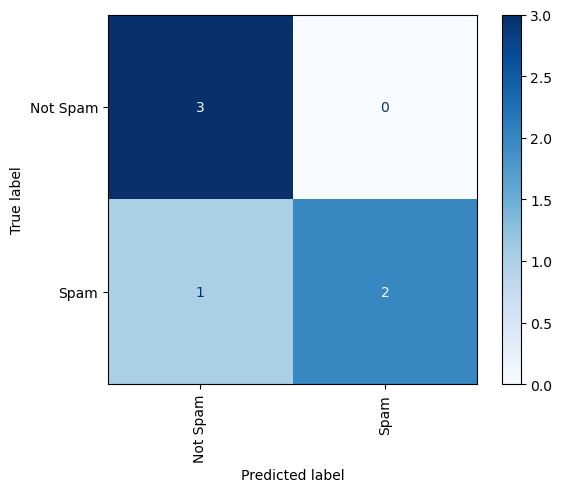

In [7]:
cmd.from_estimator(model, x_test, y_test, display_labels=['Not Spam', 'Spam'], cmap='Blues', xticks_rotation='vertical')

model.score(x_test, y_test)

### Use the model to classify short texts

The model's `predict` method predicts a class: 0 for not spam, or 1 for spam.

In [10]:
msg = '''TA office hours
Hello,

Please note that the TA (Fatema) is currently on medical leave and not available. Therefore, please direct all questions directly to me.

Best,
Reinhard'''
input = vectorizer.transform([msg])

print('class: ', model.predict(input)[0])

class:  1


### Let's get probabilities 

In [9]:
print(f'Probability Ham: {model.predict_proba(input)[0][0]:.4} | Spam: {model.predict_proba(input)[0][1]:.4}')


Probability Ham: 0.7045 | Spam: 0.2955


### Now test the model with a spam message

In [ ]:
msg = 'Congratulations, you have been selected for a free trip.'
input = vectorizer.transform([msg])

print('class: ',model.predict(input)[0])

### Let's get probabilities 

In [ ]:
print(f'Probability Ham: {model.predict_proba(input)[0][0]:.4} | Spam: {model.predict_proba(input)[0][1]:.4}')